In [1]:
!pip install yfinance scipy --quiet


In [2]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize


In [3]:
stocks = ["HDFCBANK.NS","RELIANCE.NS","TCS.NS","INFY.NS","ITC.NS"]

prices = yf.download(stocks, start="2019-01-01", auto_adjust=True)["Close"]

prices.head()


[*********************100%***********************]  5 of 5 completed


Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2019-01-01,504.392517,553.448364,201.856079,498.490570,1582.165771
2019-01-02,499.790222,556.777161,200.356644,491.998260,1599.211548
2019-01-03,495.868988,556.860474,199.107056,485.928314,1579.796265
2019-01-04,497.195618,550.119690,200.606522,488.551880,1560.588623
2019-01-07,497.946991,558.982666,201.106339,491.264496,1578.091919


In [4]:
prices.shape


(1764, 5)

In [5]:
returns = np.log(prices / prices.shift(1))
returns = returns.dropna()

returns.head()


Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2019-01-02,-0.009166,0.005997,-0.007456,-0.013109,0.010716
2019-01-03,-0.007877,0.000150,-0.006256,-0.012414,-0.012215
2019-01-04,0.002672,-0.012179,0.007503,0.005385,-0.012233
2019-01-07,0.001510,0.015983,0.002488,0.005537,0.011153
2019-01-08,-0.008358,-0.002460,0.009189,-0.000091,-0.002295


In [6]:
TRADING_DAYS = 252

mean_returns = returns.mean() * TRADING_DAYS
mean_returns


,0
Ticker,
HDFCBANK.NS,0.086841
INFY.NS,0.131829
ITC.NS,0.068314
RELIANCE.NS,0.150018
TCS.NS,0.077356


In [7]:
cov_matrix = returns.cov() * TRADING_DAYS
cov_matrix


Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,TCS.NS
Ticker,,,,,
HDFCBANK.NS,0.061607,0.020841,0.017926,0.029112,0.015958
INFY.NS,0.020841,0.076834,0.013029,0.023276,0.043513
ITC.NS,0.017926,0.013029,0.059201,0.019601,0.012051
RELIANCE.NS,0.029112,0.023276,0.019601,0.078050,0.022726
TCS.NS,0.015958,0.043513,0.012051,0.022726,0.056861


In [8]:
def portfolio_return(weights):
    return np.dot(weights, mean_returns)

def portfolio_volatility(weights):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))


In [9]:
weights = np.ones(len(stocks)) / len(stocks)

print("Return:", portfolio_return(weights))
print("Volatility:", portfolio_volatility(weights))


Return: 0.10287153772310831
Volatility: 0.17534180496547408


In [10]:
risk_free_rate = 0.06

def sharpe_ratio(weights):
    ret = portfolio_return(weights)
    vol = portfolio_volatility(weights)
    return (ret - risk_free_rate) / vol

print("Equal Weight Sharpe:", sharpe_ratio(weights))


Equal Weight Sharpe: 0.24450265999913706


In [11]:
def negative_sharpe(weights):
    return -sharpe_ratio(weights)

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0,1)] * len(stocks)

initial_guess = np.ones(len(stocks)) / len(stocks)

optimized = minimize(
    negative_sharpe,
    initial_guess,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimal_weights = optimized.x

print("Optimal Weights:")
for stock, weight in zip(stocks, optimal_weights):
    print(stock, round(weight, 3))

print("\nOptimized Return:", portfolio_return(optimal_weights))
print("Optimized Volatility:", portfolio_volatility(optimal_weights))
print("Optimized Sharpe:", sharpe_ratio(optimal_weights))


Optimal Weights:
HDFCBANK.NS 0.0
RELIANCE.NS 0.401
TCS.NS 0.0
INFY.NS 0.599
ITC.NS 0.0

Optimized Return: 0.14272387056329933
Optimized Volatility: 0.22702571727167004
Optimized Sharpe: 0.36438105584447034


In [12]:
num_portfolios = 10000

results = np.zeros((3, num_portfolios))

for i in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)

    port_ret = portfolio_return(weights)
    port_vol = portfolio_volatility(weights)
    port_sharpe = (port_ret - risk_free_rate) / port_vol

    results[0,i] = port_vol
    results[1,i] = port_ret
    results[2,i] = port_sharpe


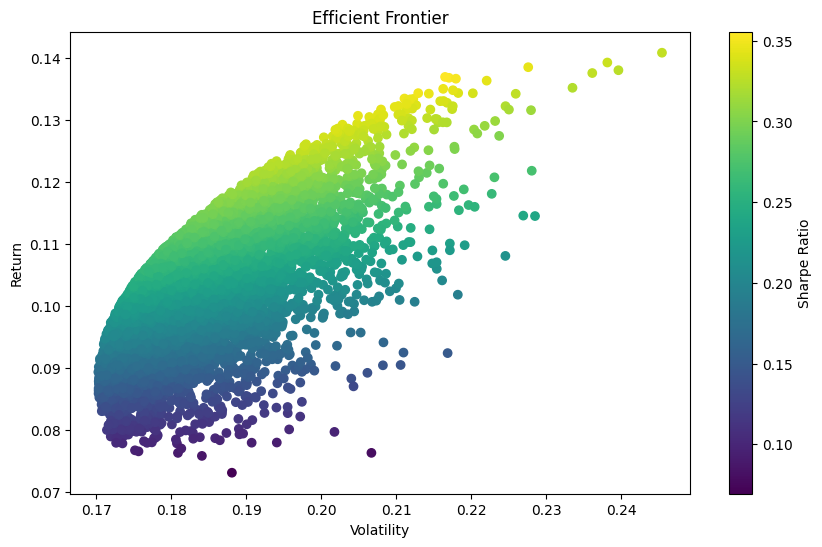

In [13]:
plt.figure(figsize=(10,6))
plt.scatter(results[0], results[1], c=results[2], cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.show()


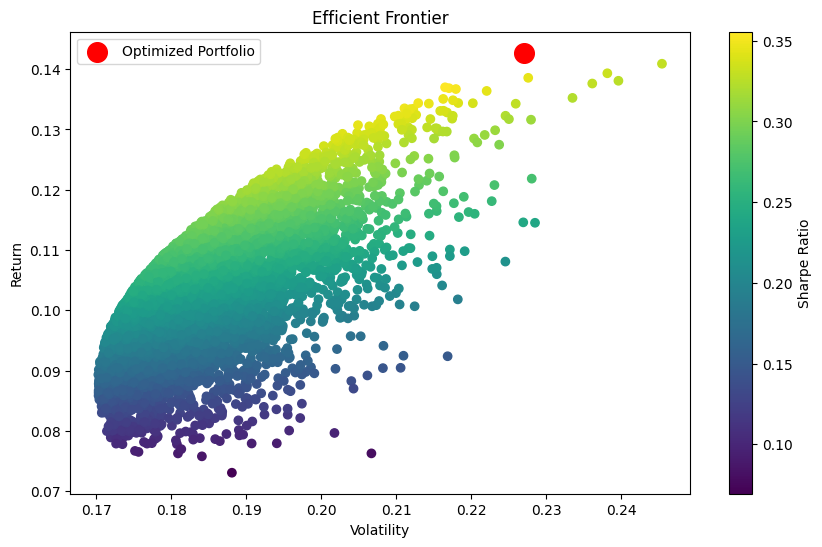

In [14]:
opt_vol = portfolio_volatility(optimal_weights)
opt_ret = portfolio_return(optimal_weights)

plt.figure(figsize=(10,6))
plt.scatter(results[0], results[1], c=results[2], cmap='viridis')
plt.colorbar(label='Sharpe Ratio')
plt.scatter(opt_vol, opt_ret, color='red', s=200, label='Optimized Portfolio')
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.legend()
plt.show()


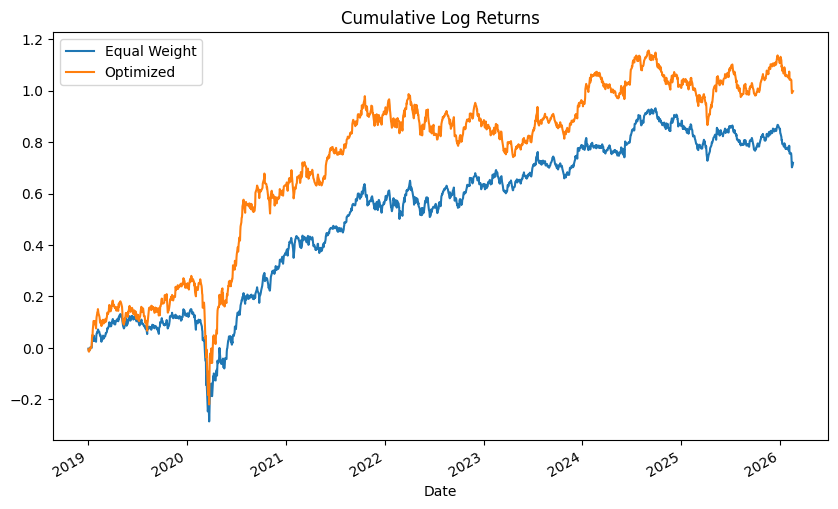

In [15]:
equal_weights = np.ones(len(stocks)) / len(stocks)

equal_returns = returns.dot(equal_weights)
opt_returns = returns.dot(optimal_weights)

plt.figure(figsize=(10,6))
(equal_returns.cumsum()).plot(label='Equal Weight')
(opt_returns.cumsum()).plot(label='Optimized')
plt.title("Cumulative Log Returns")
plt.legend()
plt.show()


In [16]:
def max_drawdown(series):
    cumulative = series.cumsum()
    peak = cumulative.cummax()
    drawdown = cumulative - peak
    return drawdown.min()

print("Equal Weight Max Drawdown:", round(max_drawdown(equal_returns)*100,2), "%")
print("Optimized Max Drawdown:", round(max_drawdown(opt_returns)*100,2), "%")


Equal Weight Max Drawdown: -43.6 %
Optimized Max Drawdown: -49.95 %


In [17]:
# Equal portfolio returns
equal_returns = returns.dot(equal_weights)

# Optimized portfolio returns
opt_returns = returns.dot(optimal_weights)

# 95% Historical VaR
equal_var = np.percentile(equal_returns, 5)
opt_var = np.percentile(opt_returns, 5)

print("Equal Portfolio Daily VaR (95%):", round(equal_var*100,2), "%")
print("Optimized Portfolio Daily VaR (95%):", round(opt_var*100,2), "%")


Equal Portfolio Daily VaR (95%): -1.53 %
Optimized Portfolio Daily VaR (95%): -1.94 %


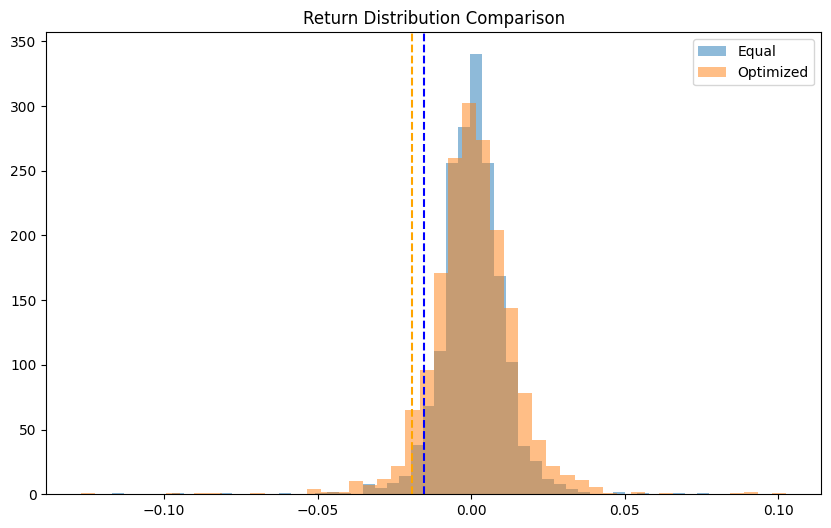

In [18]:
plt.figure(figsize=(10,6))
plt.hist(equal_returns, bins=50, alpha=0.5, label="Equal")
plt.hist(opt_returns, bins=50, alpha=0.5, label="Optimized")

plt.axvline(equal_var, color='blue', linestyle='--')
plt.axvline(opt_var, color='orange', linestyle='--')

plt.title("Return Distribution Comparison")
plt.legend()
plt.show()


In [19]:
def cvar(returns_series, alpha=5):
    var_threshold = np.percentile(returns_series, alpha)
    tail_losses = returns_series[returns_series <= var_threshold]
    return tail_losses.mean()

equal_cvar = cvar(equal_returns)
opt_cvar = cvar(opt_returns)

print("Equal Portfolio CVaR (95%):", round(equal_cvar*100,2), "%")
print("Optimized Portfolio CVaR (95%):", round(opt_cvar*100,2), "%")


Equal Portfolio CVaR (95%): -2.53 %
Optimized Portfolio CVaR (95%): -3.14 %
